In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd '/content/drive/MyDrive/Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [5]:
!pip install -q tqdm matplotlib

import json, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/ML Mini Project Output"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("Output folder ready:", OUT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Output folder ready: /content/drive/MyDrive/ML Mini Project Output
Device: cuda | Tesla T4


In [6]:
CONFIG = {
    "data_dir":    "/content/data",
    "out_dir":     OUT_DIR,
    "epochs":      50,
    "batch_size":  128,
    "vit_lr":      1e-3, "vit_wd":    0.05,
    "resnet_lr":   1e-3, "resnet_wd": 5e-4,
    "fractions":   [0.1, 0.25, 0.5, 1.0],
    "models":      ["vit", "resnet"],
    "num_workers": 2,
    "seed":        42,
}

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

In [7]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128):
        super().__init__()
        self.img_size, self.patch_size = img_size, patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, patch_size, patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class Attention(nn.Module):
    def __init__(self, dim, num_heads=4, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.last_attn = None
    def forward(self, x, save_attn=False):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        if save_attn:
            self.last_attn = attn.detach().cpu()
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))


class MLP(nn.Module):
    def __init__(self, dim, hidden_dim, drop=0.0):
        super().__init__()
        self.fc1, self.act, self.fc2 = nn.Linear(dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, dim)
        self.drop1, self.drop2 = nn.Dropout(drop), nn.Dropout(drop)
    def forward(self, x):
        return self.drop2(self.fc2(self.drop1(self.act(self.fc1(x)))))


class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=2.0, drop=0.1, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = Attention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, int(dim * mlp_ratio), drop=drop)
    def forward(self, x, save_attn=False):
        x = x + self.attn(self.norm1(x), save_attn=save_attn)
        return x + self.mlp(self.norm2(x))


class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, num_classes=10,
                 embed_dim=128, depth=6, num_heads=4, mlp_ratio=2.0,
                 drop_rate=0.1, attn_drop_rate=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        N = self.patch_embed.num_patches
        self.grid_size = self.patch_embed.grid_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, N + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, drop_rate, attn_drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)
    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x, save_attn=False):
        x = self.patch_embed(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for block in self.blocks:
            x = block(x, save_attn=save_attn)
        return self.head(self.norm(x)[:, 0])

In [8]:
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride, bias=False),
                nn.BatchNorm2d(planes),
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x), inplace=True)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(16, 3, 1)
        self.layer2 = self._make_layer(32, 3, 2)
        self.layer3 = self._make_layer(64, 3, 2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(64, num_classes)
    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        return self.fc(self.pool(x).flatten(1))


def build_model(name, num_classes=10):
    return ViT(num_classes=num_classes) if name == "vit" else ResNet20(num_classes=num_classes)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"ViT-S/4   params: {count_params(ViT()):,}")
print(f"ResNet-20 params: {count_params(ResNet20()):,}")

ViT-S/4   params: 811,146
ResNet-20 params: 272,474


In [10]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

def get_loaders(fraction, batch_size, num_workers=2, seed=42):
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    trainset = datasets.CIFAR10(CONFIG["data_dir"], train=True,  download=True, transform=train_tf)
    testset  = datasets.CIFAR10(CONFIG["data_dir"], train=False, download=True, transform=test_tf)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(trainset))[:int(len(trainset) * fraction)]
    train_subset = Subset(trainset, idx.tolist())
    return (
        DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                   num_workers=num_workers, pin_memory=True, drop_last=True),
        DataLoader(testset, batch_size=256, shuffle=False,
                   num_workers=num_workers, pin_memory=True),
    )

In [11]:
def train_one_epoch(model, loader, opt, sched, crit, device):
    model.train()
    total_loss = total_correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        out = model(x); loss = crit(out, y); loss.backward(); opt.step()
        total_loss    += loss.item() * y.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total         += y.size(0)
    sched.step()
    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval()
    total_loss = total_correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        out = model(x); loss = crit(out, y)
        total_loss    += loss.item() * y.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total         += y.size(0)
    return total_loss / total, total_correct / total

def run_single(model_name, fraction):
    set_seed(CONFIG["seed"])
    train_loader, test_loader = get_loaders(
        fraction, CONFIG["batch_size"],
        num_workers=CONFIG["num_workers"], seed=CONFIG["seed"],
    )
    model = build_model(model_name).to(device)
    lr = CONFIG["vit_lr"] if model_name == "vit" else CONFIG["resnet_lr"]
    wd = CONFIG["vit_wd"] if model_name == "vit" else CONFIG["resnet_wd"]
    opt   = AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = CosineAnnealingLR(opt, T_max=CONFIG["epochs"])
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    pbar = tqdm(range(CONFIG["epochs"]), desc=f"{model_name} f={fraction:g}", leave=False)
    for _ in pbar:
        tl, ta = train_one_epoch(model, train_loader, opt, sched, crit, device)
        vl, va = evaluate(model, test_loader, crit, device)
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["test_loss"].append(vl);  history["test_acc"].append(va)
        pbar.set_postfix(train=f"{ta:.3f}", test=f"{va:.3f}")
    return {
        "model": model_name, "fraction": fraction,
        "n_params": count_params(model),
        "final_test_acc": history["test_acc"][-1],
        "best_test_acc":  max(history["test_acc"]),
        "history": history,
    }, model

In [12]:
results = []
trained_models = {}

for m in CONFIG["models"]:
    for f in CONFIG["fractions"]:
        print(f"\n=== {m} on {int(f*100)}% of CIFAR-10 ===")
        summary, trained = run_single(m, f)
        results.append(summary)
        trained_models[(m, f)] = trained
        with open(f"{CONFIG['out_dir']}/history_{m}_{f}.json", "w") as fp:
            json.dump(summary, fp)
        print(f"  best test acc = {summary['best_test_acc']:.4f}")

with open(f"{CONFIG['out_dir']}/final_results.json", "w") as fp:
    json.dump(results, fp, indent=2)

print("\nSweep complete. Files saved to:", CONFIG["out_dir"])


=== vit on 10% of CIFAR-10 ===


100%|██████████| 170M/170M [00:10<00:00, 16.0MB/s]


vit f=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

  best test acc = 0.5661

=== vit on 25% of CIFAR-10 ===


vit f=0.25:   0%|          | 0/50 [00:00<?, ?it/s]

...

  best test acc = 0.8134

=== resnet on 50% of CIFAR-10 ===


resnet f=0.5:   0%|          | 0/50 [00:00<?, ?it/s]

  best test acc = 0.8591

=== resnet on 100% of CIFAR-10 ===


resnet f=1:   0%|          | 0/50 [00:00<?, ?it/s]

  best test acc = 0.8873

Sweep complete. Files saved to: /content/drive/MyDrive/ML Mini Project Output


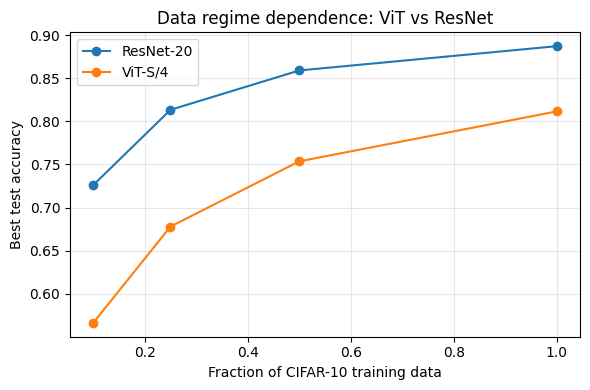

In [13]:
fractions = sorted({r["fraction"] for r in results})
label_map = {"vit": "ViT-S/4", "resnet": "ResNet-20"}

plt.figure(figsize=(6, 4))
for m in sorted({r["model"] for r in results}):
    accs = [next(r["best_test_acc"] for r in results if r["model"] == m and r["fraction"] == f)
            for f in fractions]
    plt.plot(fractions, accs, marker="o", label=label_map.get(m, m))
plt.xlabel("Fraction of CIFAR-10 training data")
plt.ylabel("Best test accuracy")
plt.title("Data regime dependence: ViT vs ResNet")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/scaling_plot.png", dpi=150)
plt.show()

Mean attention distance per layer (pixels): [15.36, 12.46, 15.29, 15.28, 15.63, 15.61]


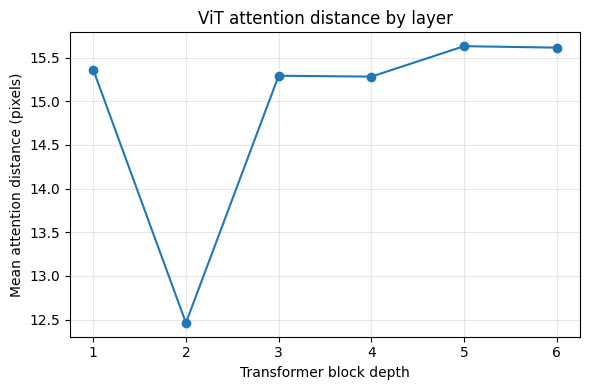

In [14]:
vit_full = trained_models[("vit", max(CONFIG["fractions"]))]
_, test_loader = get_loaders(1.0, CONFIG["batch_size"],
                             num_workers=CONFIG["num_workers"], seed=CONFIG["seed"])

@torch.no_grad()
def compute_mean_attention_distance(model, loader, device, num_batches=4):
    model.eval()
    G = model.grid_size
    coords = torch.tensor([(i, j) for i in range(G) for j in range(G)],
                          dtype=torch.float32, device=device)
    dist = torch.cdist(coords, coords)
    L = len(model.blocks)
    layer_sum = [0.0] * L
    n_items = 0
    for bi, (x, _) in enumerate(loader):
        x = x.to(device)
        _ = model(x, save_attn=True)
        B = x.size(0)
        for li, block in enumerate(model.blocks):
            a = block.attn.last_attn.to(device)
            ap = a[:, :, 1:, 1:]
            layer_sum[li] += (ap * dist).sum(dim=-1).sum().item()
        _, H, N, _ = ap.shape
        n_items += B * H * N
        if bi + 1 >= num_batches: break
    ps = model.patch_embed.patch_size
    return [s / n_items * ps for s in layer_sum]

distances = compute_mean_attention_distance(vit_full, test_loader, device)
print("Mean attention distance per layer (pixels):", [round(d, 2) for d in distances])

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(distances) + 1), distances, marker="o")
plt.xlabel("Transformer block depth")
plt.ylabel("Mean attention distance (pixels)")
plt.title("ViT attention distance by layer")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/attention_distance.png", dpi=150)
plt.show()

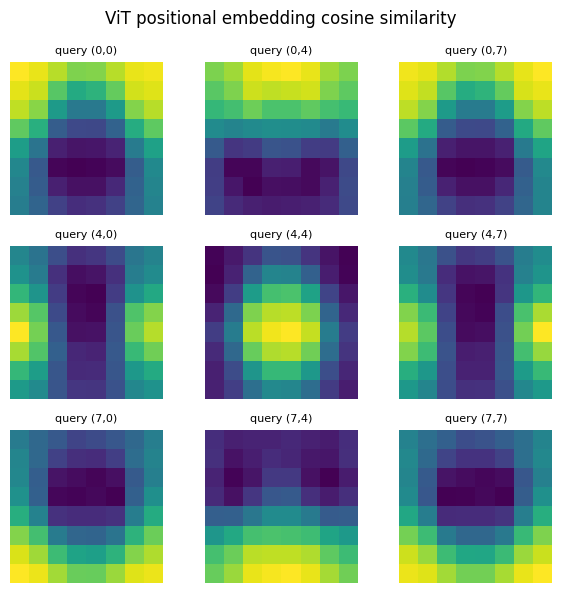

In [15]:
@torch.no_grad()
def compute_posembed_similarity(model):
    pe = model.pos_embed[0, 1:]
    pe_norm = F.normalize(pe, dim=-1)
    sim = pe_norm @ pe_norm.T
    G = model.grid_size
    return sim.reshape(G * G, G, G).cpu().numpy()

sim = compute_posembed_similarity(vit_full)
G = sim.shape[1]; N = G * G
positions = [0, G // 2, G - 1,
             (G // 2) * G, (G // 2) * G + G // 2, (G // 2) * G + G - 1,
             (G - 1) * G, (G - 1) * G + G // 2, N - 1]

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, idx in zip(axes.flat, positions):
    ax.imshow(sim[idx], cmap="viridis")
    r, c = divmod(idx, G)
    ax.set_title(f"query ({r},{c})", fontsize=8)
    ax.axis("off")
plt.suptitle("ViT positional embedding cosine similarity")
plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/posembed_similarity.png", dpi=150)
plt.show()